# Import Modules

In [4]:
from datasets import load_dataset
from gensim.models import Word2Vec
import re

d:\env_gitbash\all\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 📜 Arabic Poem Comprehensive Dataset (APCD)

## Overview
| | |
|---|---|
| **Source** | [Hugging Face](https://huggingface.co/datasets/Abdelrahman-Rezk/Arabic_Poem_Comprehensive_Dataset_APCD) |
| **Language** | Arabic 🇸🇦 |
| **Format** | Parquet |
| **Size** | 226 MB |
| **Total Rows** | 1,684,668 poem verses |

---

## Dataset Summary
> A comprehensive collection of **classical and modern Arabic poetry**,
> containing over **1.68 million verses** from hundreds of poets
> across different eras and styles.

---

## Data Fields
| Field | Type | Description |
|---|---|---|
| `العصر` | string (12 classes) | Era (e.g. العباسي, الحديث, الأموي) |
| `الشاعر` | string | Poet name |
| `الديوان` | string | Poetry collection name |
| `القافية` | string | Rhyme letter |
| `البحر` | string (23 classes) | Poetic meter (e.g. الكامل, الطويل) |
| `الشطر الايسر` | string | Left hemistich |
| `الشطر الايمن` | string | Right hemistich |
| `البيت` | string | Full verse (both hemistichs) |

---

## Data Splits
| Split | Rows |
|---|---|
| Train | 1,651,200 |
| Validation | 16,800 |
| Test | 16,668 |
| **Total** | **1,684,668** |

---

## Eras Covered
| Era | Example |
|---|---|
| الجاهلي | Pre-Islamic poetry |
| المخضرمين | Between pre-Islamic & Islamic |
| الأموي | Umayyad period |
| العباسي | Abbasid period |
| الفاطمي | Fatimid period |
| الأيوبي | Ayyubid period |
| المملوكي | Mamluk period |
| العثماني | Ottoman period |
| المغرب والأندلس | Andalusian poetry |
| الحديث | Modern poetry |

---

**Why use this for Word2Vec?**

    >   Rich classical Arabic vocabulary + 1.68M verses 
    >   strong semantic relationships between poetic words 

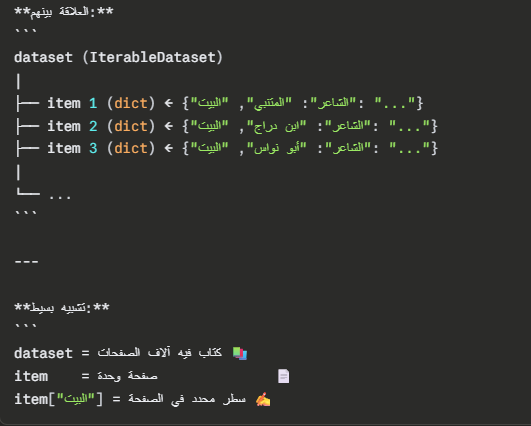

# Load the dataset

In [ ]:
print("Loading dataset...")
from datasets import load_dataset
# dataset is an iterator of dictionaries
# each dictionary is a row
dataset = load_dataset(
   "Abdelrahman-Rezk/Arabic_Poem_Comprehensive_Dataset_APCD",
    split="train",
    streaming=True   ,# Stream to avoid downloading everything
        trust_remote_code=True

)
    

Loading dataset...


# Explore the dataset

In [ ]:
dataset = load_dataset(
   "Abdelrahman-Rezk/Arabic_Poem_Comprehensive_Dataset_APCD",
    split="train",
    # streaming=True   ,# Stream to avoid downloading everything, Note : I comnented this line because it will result 
        trust_remote_code=True

)
print("=== Dataset Info ===")
print(dataset.info)

print("\n=== Dataset Format ===")
print(dataset.format)

print("\n=== Dataset Features ===")
print(dataset.features)

Generating test split: 100%|██████████| 16679/16679 [00:00<00:00, 807563.42 examples/s]


=== Dataset Info ===
DatasetInfo(description='', citation='', homepage='', license='', features={'العصر': Value(dtype='string', id=None), 'الشاعر': Value(dtype='string', id=None), 'الديوان': Value(dtype='string', id=None), 'القافية': Value(dtype='string', id=None), 'البحر': Value(dtype='string', id=None), 'الشطر الايسر': Value(dtype='string', id=None), 'الشطر الايمن': Value(dtype='string', id=None), 'البيت': Value(dtype='string', id=None)}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='arabic_poem_comprehensive_dataset_apcd', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=514353956, num_examples=1651142, shard_lengths=[1605571, 45571], dataset_name='arabic_poem_comprehensive_dataset_apcd'), 'validation': SplitInfo(name='validation', num_bytes=5245794, num_examples=16847, shard_lengths=None, dataset_name='arabic_poem_comprehensive_dataset_apcd'), 'test': SplitInfo(name='test', num_bytes=5194279, num_examples=16

In [ ]:
# ============================================================
# Show all columns
# ============================================================
print("=== ALL COLUMNS ===")
print(dataset.column_names)
print("\n=== FIRST ROW (all columns) ===")
first_row = next(iter(dataset)) #open the document (iterator) -> see the first row (next)
# first_row : is now a dictionary with all the columns
for col, value in first_row.items():
    print(f"\n[ {col} ]")
    print(f"  {value}")

=== ALL COLUMNS ===
['العصر', 'الشاعر', 'الديوان', 'القافية', 'البحر', 'الشطر الايسر', 'الشطر الايمن', 'البيت']

=== FIRST ROW (all columns) ===

[ العصر ]
  العثماني

[ الشاعر ]
  نيقولاوس الصائغ

[ الديوان ]
  الديوان الرئيسي

[ القافية ]
  م

[ البحر ]
  الكامل

[ الشطر الايسر ]
  مَعَ عَدِّها من عُصبةٍ لا ترحمُ

[ الشطر الايمن ]
  جَلَدُوهُ جَلداتٍ تَعاظمَ حَدُّها

[ البيت ]
  جلدوه جلدات تعاظم حدها    مع عدها من عصبة لا ترحم


In [44]:
# ============================================================
# 1. PEEK: show first 5 rows
# ============================================================
print("=" * 50)
print("1. FIRST 5 ROWS")
print("=" * 50)
# Iterate over the dataset and get each row an id
for i, item in enumerate(dataset):
    if i >= 5:
        break
    
    print(f"\n--- Row {i+1} ---")
    print(item["البيت"])

# ============================================================
# 2. KEYS: what columns exist in the dataset?
# ============================================================
print("\n" + "=" * 50)
print("2. COLUMN NAMES (keys)")
print("=" * 50)
first_item = next(iter(dataset))
print(f"  Keys: {list(first_item.keys())}")

# ============================================================
# 3. DATA TYPES: what type is each column?
# ============================================================
print("\n" + "=" * 50)
print("3. DATA TYPES")
print("=" * 50)
for key, value in first_item.items():
# get the type of the value then convert it to a string with __name__
    print(f"  {key}: {type(value).__name__} → '{str(value)[:50]}...'")

# ============================================================
# 4. TEXT LENGTH: how long are the texts?
# ============================================================
print("\n" + "=" * 50)
print("4. TEXT LENGTH (first 1000 rows)")
print("=" * 50)
lengths = []
for i, item in enumerate(dataset):
    if i >= 1000:
        break
    lengths.append(len(item["البيت"].split()))  # number of words

print(f"  Min words  : {min(lengths)}")
print(f"  Max words  : {max(lengths)}")
print(f"  Avg words  : {sum(lengths) // len(lengths)}")

# ============================================================
# 5. SAMPLE: show a random sample
# ============================================================
print("\n" + "=" * 50)
print("5. RANDOM SAMPLE (row 500)")
print("=" * 50)
for i, item in enumerate(dataset):
    if i == 500:
        print(item["البيت"])
        break

# ============================================================
# 6. SHORT vs LONG: count short and long texts
# ============================================================
print("\n" + "=" * 50)
print("6. SHORT vs LONG TEXTS (first 1000 rows)")
print("=" * 50)
short = 0   # less than 10 words
medium = 0  # 10 to 50 words
long = 0    # more than 50 words

for i, item in enumerate(dataset):
    if i >= 1000:
        break
    word_count = len(item["البيت"].split())
    if word_count < 10:
        short += 1
    elif word_count <= 50:
        medium += 1
    else:
        long += 1

print(f"  Short  (< 10 words) : {short}")
print(f"  Medium (10-50 words): {medium}")
print(f"  Long   (> 50 words) : {long}")

# ============================================================
# 7. CONTAINS DIGITS: how many texts have numbers?
# ============================================================
print("\n" + "=" * 50)
print("7. TEXTS CONTAINING DIGITS (first 1000 rows)")
print("=" * 50)
with_digits = 0
for i, item in enumerate(dataset):
    if i >= 1000:
        break
    if any(char.isdigit() for char in item["البيت"]):
        with_digits += 1

print(f"  Texts with digits   : {with_digits} / 1000")
print(f"  Texts without digits: {1000 - with_digits} / 1000")

# ============================================================
# 8. UNIQUE WORDS: most common words in first 500 rows
# ============================================================
print("\n" + "=" * 50)
print("8. TOP 10 MOST COMMON WORDS (first 500 rows)")
print("=" * 50)
from collections import Counter
import re

word_counter = Counter()
for i, item in enumerate(dataset):
    if i >= 500:
        break
    # Keep Arabic only
    text = re.sub(r'[^\u0600-\u06FF\s]', '', item["البيت"])
    words = text.split()
    
    word_counter.update(words)

for word, count in word_counter.most_common(10):
    print(f"  {word:20} → {count} times")

1. FIRST 5 ROWS

--- Row 1 ---
جلدوه جلدات تعاظم حدها    مع عدها من عصبة لا ترحم

--- Row 2 ---
أبوه متعب لمعانديه    وهذا الفحل من ذاك النتاج

--- Row 3 ---
من سراج في سراج بدل    انطفى ذاك وهذا سطعا

--- Row 4 ---
فعل من مال دينه أصلا أو من    كان في الدين مستقيما فمالا

--- Row 5 ---
أي شهر، ربيع عمري ولى    فيه، وارتاح في ضلوعي التياحي

2. COLUMN NAMES (keys)
  Keys: ['العصر', 'الشاعر', 'الديوان', 'القافية', 'البحر', 'الشطر الايسر', 'الشطر الايمن', 'البيت']

3. DATA TYPES
  العصر: str → 'العثماني...'
  الشاعر: str → 'نيقولاوس الصائغ...'
  الديوان: str → 'الديوان الرئيسي...'
  القافية: str → 'م...'
  البحر: str → 'الكامل...'
  الشطر الايسر: str → 'مَعَ عَدِّها من عُصبةٍ لا ترحمُ...'
  الشطر الايمن: str → 'جَلَدُوهُ جَلداتٍ تَعاظمَ حَدُّها...'
  البيت: str → 'جلدوه جلدات تعاظم حدها    مع عدها من عصبة لا ترحم...'

4. TEXT LENGTH (first 1000 rows)
  Min words  : 4
  Max words  : 14
  Avg words  : 9

5. RANDOM SAMPLE (row 500)
وعرف معروف وأنكر منكر    وطار مع العنقاء ظلم وعدوان

6. SHOR

In [46]:
for item in dataset:
    if "العنقاء" in item["البيت"]:
        print(f"الشاعر : {item['الشاعر']}")
        print(f"الديوان: {item['الديوان']}")
        print(f"العصر  : {item['العصر']}")
        print(f"البيت  : {item['البيت']}")
        break

الشاعر : ابن دراج القسطلي
الديوان: الديوان الرئيسي
العصر  : المغرب والأندلس
البيت  : وعرف معروف وأنكر منكر    وطار مع العنقاء ظلم وعدوان


 # Preprocessing 

In [48]:
# Step 2: Clean and tokenize the text
# ============================================================
def clean_and_tokenize(text):
    # Keep only Arabic characters and spaces
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    # Split into word tokens
    tokens = text.split()
    return tokens

sentences = []
MAX_SENTENCES = 100_000  # Adjust based on your machine's memory

print("Processing Peoms...")
for i, item in enumerate(dataset):
    if i >= MAX_SENTENCES:
        break
    tokens = clean_and_tokenize(item["البيت"])
    if len(tokens) > 5:   # Skip very short sentences
        sentences.append(tokens)

print(f"Total sentences loaded: {len(sentences):,}")

Processing Peoms...
Total sentences loaded: 98,912


 # Training our embedding model 

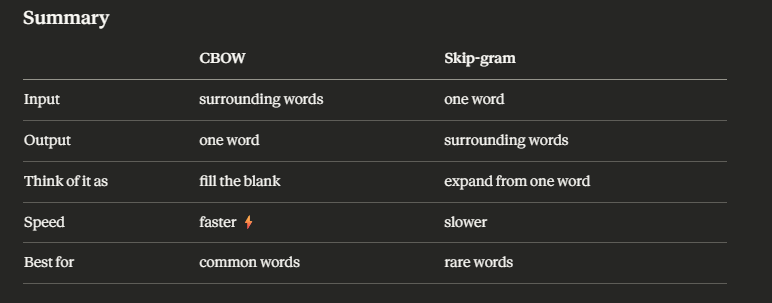

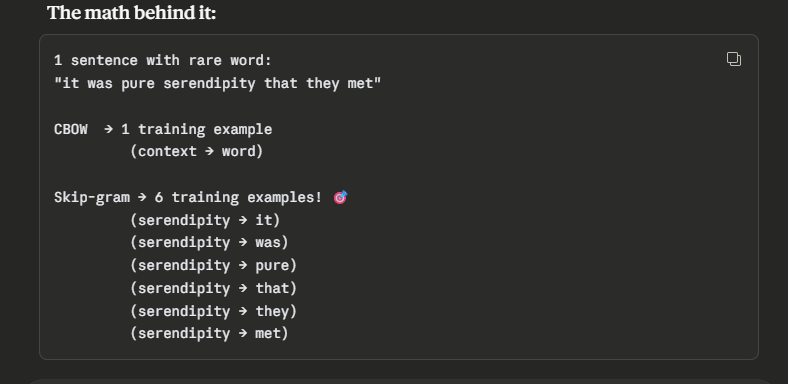

## CBOW model

In [ ]:
# Step 3: Train CBOW model  (sg=0)
# Predicts a word from its surrounding context words
# ============================================================
print("\nTraining CBOW model...")

cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # Number of embedding dimensions
    window=5,          # Context window size (words left and right) xxxx_  . we want to know about _ . 
    min_count=5,       # Ignore words that appear less than 5 times . rare words don't matter in CBOW
    workers=4,         # Number of CPU threads
    sg=0,              # 0 = CBOW ✅
    epochs=5           # Number of training passes over the data
)

cbow_model.save("cbow_arabic.model")
print("CBOW model saved!")


Training CBOW model...
CBOW model saved!


## Skip-gram model


In [52]:
# Step 4: Train Skip-gram model  (sg=1)
# Predicts surrounding context words from a single word
# ============================================================
print("\nTraining Skip-gram model...")

skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,              # 1 = Skip-gram ✅
    epochs=5
)

skipgram_model.save("skipgram_arabic.model")
print("Skip-gram model saved!")


Training Skip-gram model...
Skip-gram model saved!


# Evaluate the results 

In [54]:
from gensim.models import Word2Vec
import numpy as np

# ============================================================
# Load your trained models
# ============================================================
cbow_model     = Word2Vec.load("cbow_arabic.model")
skipgram_model = Word2Vec.load("skipgram_arabic.model")

# ============================================================
# 1. SIMILARITY TEST
#    How similar are related words? (higher = better)
# ============================================================
print("=" * 50)
print("1. SIMILARITY TEST")
print("=" * 50)

pairs = [
    ("قلب", "روح"),      # should be similar ✅
    ("ليل", "نهار"),     # opposites
    ("حب", "عشق"),       # synonyms — should be very similar ✅
    ("شمس", "قمر"),      # related
    ("قلب", "سيارة"),    # totally unrelated — should be low ✅
]

print(f"\n{'Pair':30} {'CBOW':10} {'Skip-gram':10}")
print("-" * 50)
for w1, w2 in pairs:
    if w1 in cbow_model.wv and w2 in cbow_model.wv:
        cbow_score = cbow_model.wv.similarity(w1, w2)
        sg_score   = skipgram_model.wv.similarity(w1, w2)
        print(f"  {w1} ↔ {w2:20} {cbow_score:.4f}     {sg_score:.4f}")
    else:
        print(f"  {w1} ↔ {w2} ← not in vocabulary ❌")

# ============================================================
# 2. ANALOGY TEST
#    king - man + woman = queen (higher = better)
# ============================================================
print("\n" + "=" * 50)
print("2. ANALOGY TEST")
print("=" * 50)

analogies = [
    ("ليل", "ظلام", "نهار"),    # ليل:ظلام = نهار:؟
    ("شمس", "نور",  "قمر"),     # شمس:نور  = قمر:؟
    
    ("ملك", "قصر",  "فقير"),    # ملك:قصر  = فقير:؟
]

for w1, w2, w3 in analogies:
    if all(w in cbow_model.wv for w in [w1, w2, w3]):
        print(f"\n  {w1}:{w2} = {w3}:???")

        print("  CBOW →")
        result = cbow_model.wv.most_similar(
            positive=[w2, w3], negative=[w1], topn=3
        )
        for word, score in result:
            print(f"    {word:15} → {score:.4f}")

        print("  Skip-gram →")
        result = skipgram_model.wv.most_similar(
            positive=[w2, w3], negative=[w1], topn=3
        )
        for word, score in result:
            print(f"    {word:15} → {score:.4f}")
    else:
        print(f"\n  {w1},{w2},{w3} ← some words not in vocabulary ❌")

# ============================================================
# 3. ODD ONE OUT TEST
#    Find the word that doesn't belong
# ============================================================
print("\n" + "=" * 50)
print("3. ODD ONE OUT TEST")
print("=" * 50)

groups = [
    ["قلب", "روح", "حب", "سيارة"],
    ["ليل", "نهار", "فجر", "كتاب"],
    ["شمس", "قمر", "نجم", "بحر"],
]

for group in groups:
    if all(w in cbow_model.wv for w in group):
        cbow_odd = cbow_model.wv.doesnt_match(group)
        sg_odd   = skipgram_model.wv.doesnt_match(group)
        print(f"\n  Group   : {group}")
        print(f"  CBOW    : odd one = '{cbow_odd}'")
        print(f"  Skip-gram: odd one = '{sg_odd}'")

# ============================================================
# 4. VOCABULARY COVERAGE
#    How many words did the model learn?
# ============================================================
print("\n" + "=" * 50)
print("4. VOCABULARY COVERAGE")
print("=" * 50)
print(f"  CBOW vocab size     : {len(cbow_model.wv):,} words")
print(f"  Skip-gram vocab size: {len(skipgram_model.wv):,} words")

# ============================================================
# 5. MOST SIMILAR — quality check
#    Do similar words make sense?
# ============================================================
print("\n" + "=" * 50)
print("5. MOST SIMILAR — QUALITY CHECK")
print("=" * 50)

test_words = ["قلب", "ليل", "حب", "شعر"]

for word in test_words:
    if word in cbow_model.wv:
        print(f"\n  Word: '{word}'")
        print(f"  CBOW →")
        for w, score in cbow_model.wv.most_similar(word, topn=3):
            print(f"    {w:15} → {score:.4f}")
        print(f"  Skip-gram →")
        for w, score in skipgram_model.wv.most_similar(word, topn=3):
            print(f"    {w:15} → {score:.4f}")

# ============================================================
# 6. OVERALL SCORE — average similarity of related pairs
#    closer to 1 = better model
# ============================================================
print("\n" + "=" * 50)
print("6. OVERALL SCORE")
print("=" * 50)

related_pairs = [
    ("قلب", "روح"),
    ("حب",  "عشق"),
    ("ليل", "ظلام"),
    ("شمس", "نور"),
    ("شعر", "قصيدة"),
]

cbow_scores = []
sg_scores   = []

for w1, w2 in related_pairs:
    if w1 in cbow_model.wv and w2 in cbow_model.wv:
        cbow_scores.append(cbow_model.wv.similarity(w1, w2))
        sg_scores.append(skipgram_model.wv.similarity(w1, w2))

if cbow_scores:
    print(f"  CBOW avg similarity     : {np.mean(cbow_scores):.4f}")
    print(f"  Skip-gram avg similarity: {np.mean(sg_scores):.4f}")
    winner = "CBOW" if np.mean(cbow_scores) > np.mean(sg_scores) else "Skip-gram"
    print(f"\n  Winner: {winner} 🏆")

1. SIMILARITY TEST

Pair                           CBOW       Skip-gram 
--------------------------------------------------
  قلب ↔ روح                  0.9634     0.8458
  ليل ↔ نهار                 0.9737     0.8348
  حب ↔ عشق                  0.9863     0.9225
  شمس ↔ قمر                  0.9898     0.8571
  قلب ↔ سيارة                0.8975     0.6967

2. ANALOGY TEST

  ليل:ظلام = نهار:???
  CBOW →
    الأنجم          → 0.9895
    مشي             → 0.9894
    يرف             → 0.9887
  Skip-gram →
    ضرب             → 0.9609
    تبدو            → 0.9584
    الخوف           → 0.9579

  شمس:نور = قمر:???
  CBOW →
    مطلع            → 0.9945
    سماء            → 0.9943
    رفيع            → 0.9936
  Skip-gram →
    طرف             → 0.9288
    صبح             → 0.9234
    الآفاق          → 0.9230

  ملك:قصر = فقير:???
  CBOW →
    تري             → 0.9928
    تظهر            → 0.9922
    أرد             → 0.9920
  Skip-gram →
    هواي            → 0.9507
    لوم             → 0.94

In [55]:
test_word = "ملك"  # "king" in Arabic

print(f"\n=== Most similar words to '{test_word}' ===")

print("\n[ CBOW ]")
for word, score in cbow_model.wv.most_similar(test_word, topn=5):
    print(f"  {word:15} → {score:.4f}")


print("\n[ Skip-gram ]")
for word, score in skipgram_model.wv.most_similar(test_word, topn=5):
    print(f"  {word:15} → {score:.4f}")


=== Most similar words to 'ملك' ===

[ CBOW ]
  بحر             → 0.9957
  الجمال          → 0.9957
  الملوك          → 0.9954
  الحمد           → 0.9949
  الأنام          → 0.9944

[ Skip-gram ]
  أعلى            → 0.9500
  شرف             → 0.9479
  الكمال          → 0.9478
  العلا           → 0.9449
  فخر             → 0.9442


# Load the model to improve the results later on 

In [56]:
# ============================================================
# Step 6: Load saved models later
# ============================================================
print("\n" + "=" * 50)
print("11. LOAD CUSTOM TRAINED MODELS")
print("=" * 50)
cbow_model     = Word2Vec.load("cbow_arabic.model")
skipgram_model = Word2Vec.load("skipgram_arabic.model")
print("  CBOW model loaded     ✅")
print("  Skip-gram model loaded ✅")


11. LOAD CUSTOM TRAINED MODELS
  CBOW model loaded     ✅
  Skip-gram model loaded ✅


# Update the model with more vocabulary words (continuous learning)


In [57]:
# ============================================================
# 16. CONTINUE TRAINING: add more data to your custom model
# ============================================================
print("\n" + "=" * 50)
print("16. CONTINUE TRAINING on new sentences")
print("=" * 50)
new_sentences = [
    ["الرئيس", "يحكم", "البلاد"],
    ["الملك", "يجلس", "على", "العرش"],
    ["الوزير", "يدير", "الحكومة"],
]
# Update vocabulary first, then train
cbow_model.build_vocab(new_sentences, update=True)
cbow_model.train(
    new_sentences,
    total_examples=len(new_sentences),
    epochs=cbow_model.epochs
)
cbow_model.save("cbow_arabic_updated.model")
print("  Model updated and saved ✅")




16. CONTINUE TRAINING on new sentences
  Model updated and saved ✅
